# Pathway analysis    ---- UNCHANGED FROM YO all

In [3]:
import scanpy as sc
import decoupler as dc

# Only needed for processing
import numpy as np
import pandas as pd

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [4]:
comparison = 'young.vs.old'
experiment = "RNAseq_abundances_adjusted_combat_inmose"


In [ ]:
'/home/amore/work/data/RNAseq_abundances_adjusted_combat_inmose_young.vs.old_DDS.csv'

In [5]:
dds = pd.read_csv(f'/home/amore/work/data/{experiment}_{comparison}_DDS.csv',index_col=0)
dds

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
TSPAN6,6.652061e+07,-0.039065,0.104623,-0.373394,0.708855,0.907432
TNMD,1.376112e+05,-0.426688,1.395668,-0.305723,0.759815,0.924157
DPM1,9.614235e+07,-0.145930,0.158111,-0.922960,0.356028,0.693475
SCYL3,1.268802e+07,-1.493229,0.706095,-2.114769,0.034450,0.158123
FIRRM,3.481744e+07,-1.009579,0.447366,-2.256718,0.024026,0.123501
...,...,...,...,...,...,...
C4orf36.1,5.664924e+07,-0.351695,0.220923,-1.591932,0.111400,0.346605
Unnamed: 34327,5.890034e+05,-0.088741,1.216048,-0.072975,0.941826,0.982119
H2BK1,9.477206e+05,0.010106,1.014972,0.009957,0.992056,0.997164
Unnamed: 34332,5.902246e+06,1.001606,0.743051,1.347965,0.177670,0.466165


In [6]:
results_df =dds

In [51]:
### get elbow point
elbow = 2

dds_de = dds[(abs(dds['log2FoldChange'])>elbow) & (dds['padj']<0.01)]
dds_de

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
SEMA3F,1.720695e+06,-4.102241,0.772582,-5.309781,1.097573e-07,3.923129e-06
CFTR,1.715479e+06,-3.346279,0.888963,-3.764250,1.670498e-04,2.384172e-03
MYH16,7.060173e+04,7.573264,0.787617,9.615413,6.883250e-22,2.130282e-19
ARF5,5.221438e+05,-4.739374,0.841104,-5.634707,1.753562e-08,7.719199e-07
FKBP4,8.184785e+06,-3.040114,0.762104,-3.989105,6.632305e-05,1.078940e-03
...,...,...,...,...,...,...
C2orf81,1.965189e+04,-3.319408,0.746568,-4.446224,8.739267e-06,1.930245e-04
Unnamed: 34127,8.246822e+05,-4.548194,0.812726,-5.596217,2.190797e-08,9.391561e-07
Unnamed: 34254,3.248561e+07,-2.382550,0.620279,-3.841096,1.224863e-04,1.823142e-03
Unnamed: 34260,2.311775e+06,-3.038266,0.760715,-3.993960,6.497871e-05,1.062519e-03


## Get msigdb

In [8]:
msigdb = dc.get_resource('MSigDB')
msigdb# Sort the results by the ranking metric (e.g., log2 fold change)


,genesymbol,collection,geneset
0,MAFF,chemical_and_genetic_perturbations,BOYAULT_LIVER_CANCER_SUBCLASS_G56_DN
1,MAFF,chemical_and_genetic_perturbations,ELVIDGE_HYPOXIA_UP
2,MAFF,chemical_and_genetic_perturbations,NUYTTEN_NIPP1_TARGETS_DN
3,MAFF,immunesigdb,GSE17721_POLYIC_VS_GARDIQUIMOD_4H_BMDC_DN
4,MAFF,chemical_and_genetic_perturbations,SCHAEFFER_PROSTATE_DEVELOPMENT_12HR_UP
...,...,...,...
3838543,PRAMEF22,go_biological_process,GOBP_POSITIVE_REGULATION_OF_CELL_POPULATION_PR...
3838544,PRAMEF22,go_biological_process,GOBP_APOPTOTIC_PROCESS
3838545,PRAMEF22,go_biological_process,GOBP_REGULATION_OF_CELL_DEATH
3838546,PRAMEF22,go_biological_process,GOBP_NEGATIVE_REGULATION_OF_DEVELOPMENTAL_PROCESS


In [9]:
# Filter by hallmark
#msigdb = msigdb[msigdb['collection']=='hallmark']

# Remove duplicated entries
msigdb = msigdb[~msigdb.duplicated(['geneset', 'genesymbol'])]

# Rename
#msigdb.loc[:, 'geneset'] = [name.split('HALLMARK_')[1] for name in msigdb['geneset']]

msigdb

,genesymbol,collection,geneset
0,MAFF,chemical_and_genetic_perturbations,BOYAULT_LIVER_CANCER_SUBCLASS_G56_DN
1,MAFF,chemical_and_genetic_perturbations,ELVIDGE_HYPOXIA_UP
2,MAFF,chemical_and_genetic_perturbations,NUYTTEN_NIPP1_TARGETS_DN
3,MAFF,immunesigdb,GSE17721_POLYIC_VS_GARDIQUIMOD_4H_BMDC_DN
4,MAFF,chemical_and_genetic_perturbations,SCHAEFFER_PROSTATE_DEVELOPMENT_12HR_UP
...,...,...,...
3838543,PRAMEF22,go_biological_process,GOBP_POSITIVE_REGULATION_OF_CELL_POPULATION_PR...
3838544,PRAMEF22,go_biological_process,GOBP_APOPTOTIC_PROCESS
3838545,PRAMEF22,go_biological_process,GOBP_REGULATION_OF_CELL_DEATH
3838546,PRAMEF22,go_biological_process,GOBP_NEGATIVE_REGULATION_OF_DEVELOPMENTAL_PROCESS


In [10]:
set(msigdb["collection"])

{'biocarta_pathways',
 'cancer_gene_neighborhoods',
 'cancer_modules',
 'cell_type_signatures',
 'chemical_and_genetic_perturbations',
 'go_biological_process',
 'go_cellular_component',
 'go_molecular_function',
 'hallmark',
 'human_phenotype_ontology',
 'immunesigdb',
 'kegg_pathways',
 'mirna_targets_legacy',
 'mirna_targets_mirdb',
 'oncogenic_signatures',
 'pid_pathways',
 'positional',
 'reactome_pathways',
 'tf_targets_gtrf',
 'tf_targets_legacy',
 'vaccine_response',
 'wikipathways'}

## GSEA

In [10]:
# Prepare the ranking for GSEA
ranked_genes = results_df[['log2FoldChange']].sort_values(by='log2FoldChange', ascending=False)

# Prepare the ranking for GSEA
gene_list = ranked_genes['log2FoldChange']
gene_list.index = results_df.index  # Ensure the gene symbols are in the index
pd.DataFrame(gene_list)

,log2FoldChange
TSPAN6,14.788157
TNMD,14.022549
DPM1,12.880724
SCYL3,11.580810
FIRRM,10.561955
...,...
C4orf36.1,-16.905359
Unnamed: 34327,-16.950502
H2BK1,-19.692881
Unnamed: 34332,-19.817974


In [11]:

# Run GSEA
enr_gsea = dc.get_gsea_df(
    df=dds,
    stat="stat",
    net=msigdb,
    source='geneset',
    target='genesymbol'
)

# Display the top enrichment results
enr_gsea.head()

,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge
0,AAACCAC_MIR140,-0.283158,-0.930418,0.618997,0.797401,103,0.417476,0.296674,COL23A1;SOX4;HNRNPH3;TSPAN2;SLC25A13;NSD3;SLC4...
1,AAAGACA_MIR511,-0.319973,-1.099519,0.270855,0.555768,185,0.372973,0.261329,CLTC;NR4A2;KCNMA1;ANKZF1;PAX8;GEMIN2;BTG1;UBE2...
2,AAAGGAT_MIR501,-0.355503,-1.182581,0.175345,0.456151,120,0.500000,0.292419,CCDC140;SCN3A;LEPROTL1;PHF6;RPGRIP1L;CELF2;SOX...
3,AAAGGGA_MIR204_MIR211,-0.396859,-1.378850,0.006085,0.074698,211,0.345972,0.223974,CPD;NR4A2;GAPVD1;PABIR2;LPAR1;ZFC3H1;PCDH9;TRI...
4,AAANWWTGC_UNKNOWN,-0.281157,-0.957670,0.601634,0.787617,178,0.460674,0.338088,ASPA;TFAP4;ZNF827;SOX4;PCSK1;CACNG3;ANK3;CD14;...


In [12]:
enr_gsea.to_csv(f'/home/amore/work/data/{experiment}_{comparison}_GSEA.csv', header=True)

In [13]:
significant_GSEA = enr_gsea[enr_gsea["FDR p-value"] < 0.1].sort_values(by="NES")
significant_GSEA

,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge
12737,GRAHAM_CML_QUIESCENT_VS_CML_DIVIDING_UP,-0.787030,-1.986368,0.0,0.0,19,0.631579,0.124123,PCDH9;IL1B;CXCL2;CXCL13;TNFSF4;H2AC6;CRHBP;ZBT...
28478,PYEON_CANCER_HEAD_AND_NECK_VS_CERVICAL_UP,-0.583559,-1.974719,0.0,0.0,180,0.605556,0.245015,NR4A2;SPICE1;PRPF39;SS18L1;GART;ATAD2;HNRNPU;P...
15018,GSE25146_UNSTIM_VS_HELIOBACTER_PYLORI_LPS_STIM...,-0.556678,-1.893409,0.0,0.0,160,0.568750,0.253054,CD69;ARID4B;SENP5;TBC1D2B;MTA3;DDX17;CMAHP;ERB...
2506,GNF2_DDX5,-0.626568,-1.881675,0.0,0.0,61,0.557377,0.187091,PHF11;SCAF11;CRBN;SRSF6;RSRP1;ARHGAP4;TYK2;NIP...
23475,HUTTMANN_B_CLL_POOR_SURVIVAL_DN,-0.612797,-1.872892,0.0,0.0,56,0.500000,0.174955,ZNF280D;BANK1;EAF2;MYBL1;VNN2;FUT8;SMC5;TCAF1;...
...,...,...,...,...,...,...,...,...,...
29703,REACTOME_RESPIRATORY_ELECTRON_TRANSPORT_ATP_SY...,0.760510,3.321661,0.0,0.0,122,0.549180,0.065844,SDHA;NDUFV3;NDUFA12;COX5B;NDUFAF3;ATP5MF;MT-CO...
30026,REACTOME_THE_CITRIC_ACID_TCA_CYCLE_AND_RESPIRA...,0.753504,3.359083,0.0,0.0,171,0.514620,0.065844,SDHA;NDUFV3;NDUFA12;COX5B;NDUFAF3;ATP5MF;MT-CO...
7633,GOBP_PROTON_MOTIVE_FORCE_DRIVEN_ATP_SYNTHESIS,0.815678,3.370862,0.0,0.0,73,0.671233,0.083498,SDHA;NDUFV3;NDUFA12;ATP5MF;ATP5MK;ATP5PB;SDHB;...
23823,KEGG_OXIDATIVE_PHOSPHORYLATION,0.742875,3.378207,0.0,0.0,123,0.512195,0.083498,SDHA;NDUFV3;COX5B;ATP5MF;ATP5PB;MT-CO2;SDHB;CO...


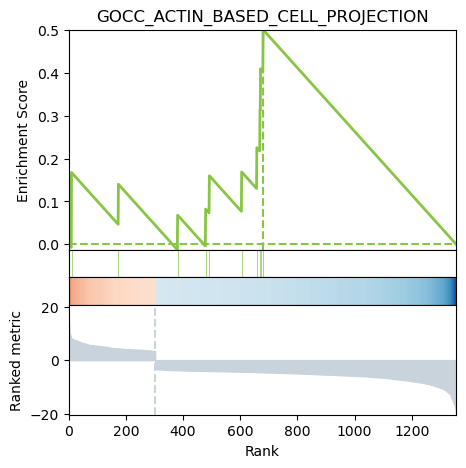

In [14]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb,
    source='geneset',
    target='genesymbol',
    set_name='GOCC_ACTIN_BASED_CELL_PROJECTION'
)

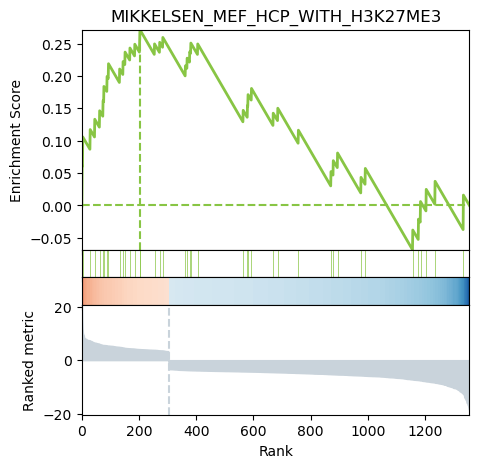

In [15]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb,
    source='geneset',
    target='genesymbol',
    set_name='MIKKELSEN_MEF_HCP_WITH_H3K27ME3'
)

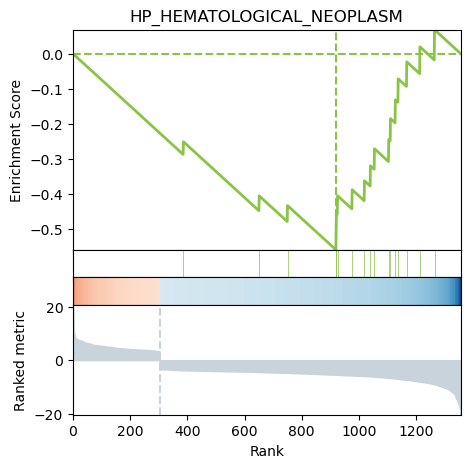

In [16]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb,
    source='geneset',
    target='genesymbol',
    set_name='HP_HEMATOLOGICAL_NEOPLASM'
)

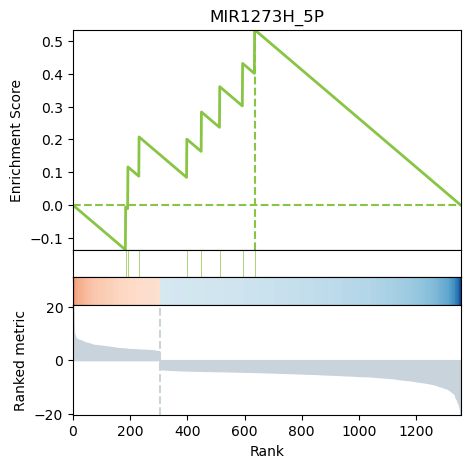

In [17]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb,
    source='geneset',
    target='genesymbol',
    set_name='MIR1273H_5P'
)

## ORA

In [28]:
results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
TSPAN6,6.652061e+07,-0.039065,0.104623,-0.373394,0.708855,0.907432
TNMD,1.376112e+05,-0.426688,1.395668,-0.305723,0.759815,0.924157
DPM1,9.614235e+07,-0.145930,0.158111,-0.922960,0.356028,0.693475
SCYL3,1.268802e+07,-1.493229,0.706095,-2.114769,0.034450,0.158123
FIRRM,3.481744e+07,-1.009579,0.447366,-2.256718,0.024026,0.123501
...,...,...,...,...,...,...
C4orf36.1,5.664924e+07,-0.351695,0.220923,-1.591932,0.111400,0.346605
Unnamed: 34327,5.890034e+05,-0.088741,1.216048,-0.072975,0.941826,0.982119
H2BK1,9.477206e+05,0.010106,1.014972,0.009957,0.992056,0.997164
Unnamed: 34332,5.902246e+06,1.001606,0.743051,1.347965,0.177670,0.466165


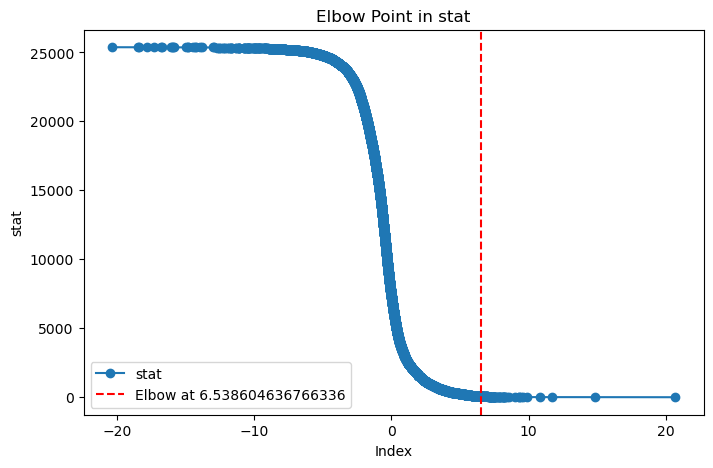

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from kneed import KneeLocator

# Example DataFrame
df = dds

# Step 1: Sort by log2FoldChange (ascending or descending)
df = df.sort_values(by='stat', ascending=False).reset_index(drop=True)

# Step 2: Normalize values (optional)
y = np.arange(len(df))  # Indices (gene positions)
x = df['stat'].values

# Step 3: Apply Kneedle algorithm to find the elbow point
kneedle = KneeLocator(x, y, curve='convex', direction='decreasing')  # Direction depends on sorting
elbow_point = kneedle.elbow

# Plot the log2FoldChange with the detected elbow point
plt.figure(figsize=(8, 5))
plt.plot(x, y, label='stat', marker='o')
plt.axvline(elbow_point, color='red', linestyle='--', label=f'Elbow at {elbow_point}')
plt.title('Elbow Point in stat')
plt.xlabel('Index')
plt.ylabel('stat')
plt.legend()
plt.show()

In [103]:
elbow_point

6.538604636766336

In [104]:
### get elbow point
elbow = elbow_point

dds_de = dds[(abs(dds['stat'])>elbow) & (dds['padj']<0.1)]

dds_de.sort_values(by='log2FoldChange')

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
SGCZ,1.838463e+04,-19.817974,1.334669,-14.848602,7.103446e-50,1.201808e-46
RIMKLBP2,5.082031e+03,-19.692881,1.412759,-13.939309,3.654633e-44,4.637364e-41
EIF1AXP1,2.076085e+06,-16.950502,1.057212,-16.033207,7.491532e-58,2.053085e-54
RPL21P72,4.560781e+05,-16.905359,1.007775,-16.774936,3.722570e-63,1.349591e-59
GLYATL1,1.495215e+05,-16.427919,0.889793,-18.462632,4.127313e-76,3.491432e-72
...,...,...,...,...,...,...
RSPO1,2.378095e+04,10.561955,0.977382,10.806374,3.211129e-27,1.771566e-24
Unnamed: 31262,1.959940e+04,11.580810,1.428281,8.108213,5.136946e-16,8.250976e-14
MTCO1P24,8.601578e+04,12.880724,1.098711,11.723488,9.661030e-32,7.211107e-29
KL,2.233075e+06,14.022549,0.944673,14.843816,7.628968e-50,1.210050e-46


In [105]:
top_genes = list(dds_de[dds_de['padj'] < 0.05].index)

len(top_genes)

335

In [50]:
dds

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
TSPAN6,6.652061e+07,-0.039065,0.104623,-0.373394,0.708855,0.907432
TNMD,1.376112e+05,-0.426688,1.395668,-0.305723,0.759815,0.924157
DPM1,9.614235e+07,-0.145930,0.158111,-0.922960,0.356028,0.693475
SCYL3,1.268802e+07,-1.493229,0.706095,-2.114769,0.034450,0.158123
FIRRM,3.481744e+07,-1.009579,0.447366,-2.256718,0.024026,0.123501
...,...,...,...,...,...,...
C4orf36.1,5.664924e+07,-0.351695,0.220923,-1.591932,0.111400,0.346605
Unnamed: 34327,5.890034e+05,-0.088741,1.216048,-0.072975,0.941826,0.982119
H2BK1,9.477206e+05,0.010106,1.014972,0.009957,0.992056,0.997164
Unnamed: 34332,5.902246e+06,1.001606,0.743051,1.347965,0.177670,0.466165


In [94]:
top_genes[:3]

['MYH16', 'ARF5', 'ARHGAP33']

In [ ]:
list(dds.index)

In [108]:
# Infer enrichment with ora using significant deg

# Run ora
enr_pvals = dc.get_ora_df(
    df=top_genes,#[:10],
    net=msigdb,
    source='geneset',
    target='genesymbol'
)

enr_pvals.head()

,Term,Set size,Overlap ratio,p-value,FDR p-value,Odds ratio,Combined score,Features
0,AAACCAC_MIR140,110,0.009091,0.844829,1.0,0.807195,0.136110,TAF9B
1,AAAGGAT_MIR501,127,0.007874,0.883762,1.0,0.698971,0.086371,SLC25A3
2,AAAGGGA_MIR204_MIR211,224,0.008929,0.891850,1.0,0.660355,0.075582,PLAG1;SGCZ
3,AAAYRNCTG_UNKNOWN,370,0.013514,0.745388,1.0,0.881727,0.259096,ATP5MG;KLHDC10;KLHL20;SCN5A;SPINDOC
4,AAAYWAACM_HFH4_01,260,0.011538,0.813724,1.0,0.797677,0.164429,CADM2;PBX1;SLC39A8


In [110]:
enr_pvals.to_csv(f'/home/amore/work/data/{experiment}_{comparison}_ORA.csv', header=True)

In [109]:
significant_ORA = enr_pvals[(enr_pvals["p-value"] < 0.1) & (enr_pvals["FDR p-value"] < 0.15)]
significant_ORA

,Term,Set size,Overlap ratio,p-value,FDR p-value,Odds ratio,Combined score,Features
2201,GOBP_MITOCHONDRIAL_ELECTRON_TRANSPORT_CYTOCHRO...,24,0.208333,0.000042,0.141564,13.568897,136.790511,COX4I1;COX5B;COX7C;CYCS;MT-CO2
8754,HALLMARK_OXIDATIVE_PHOSPHORYLATION,200,0.065000,0.000035,0.141564,4.133956,42.470246,ATP5MC3;ATP5MG;COX4I1;COX5B;COX7C;CYCS;LDHA;ND...
10924,KEGG_OXIDATIVE_PHOSPHORYLATION,129,0.077519,0.000064,0.141564,4.949931,47.783144,ATP5MC3;ATP5MG;COX4I1;COX5B;COX7C;MT-CO2;NDUFB...
13111,MOOTHA_VOXPHOS,87,0.103448,0.000015,0.117128,6.621860,73.473112,ATP5MC3;ATP5MG;COX4I1;COX5B;COX7C;CYCS;NDUFB4;...
14019,REACTOME_RESPIRATORY_ELECTRON_TRANSPORT_ATP_SY...,127,0.078740,0.000056,0.141564,5.028083,49.204285,ATP5MC3;ATP5MG;COX4I1;COX5B;COX7C;CYCS;MT-CO2;...
14097,REACTOME_THE_CITRIC_ACID_TCA_CYCLE_AND_RESPIRA...,178,0.073034,0.000010,0.117128,4.648622,53.505813,ATP5MC3;ATP5MG;COX4I1;COX5B;COX7C;CYCS;LDHA;MT...
14847,WP_ELECTRON_TRANSPORT_CHAIN_OXPHOS_SYSTEM_IN_M...,103,0.087379,0.000059,0.141564,5.593692,54.492723,ATP5MC3;ATP5MG;COX4I1;COX5B;COX7C;MT-CO2;NDUFB...


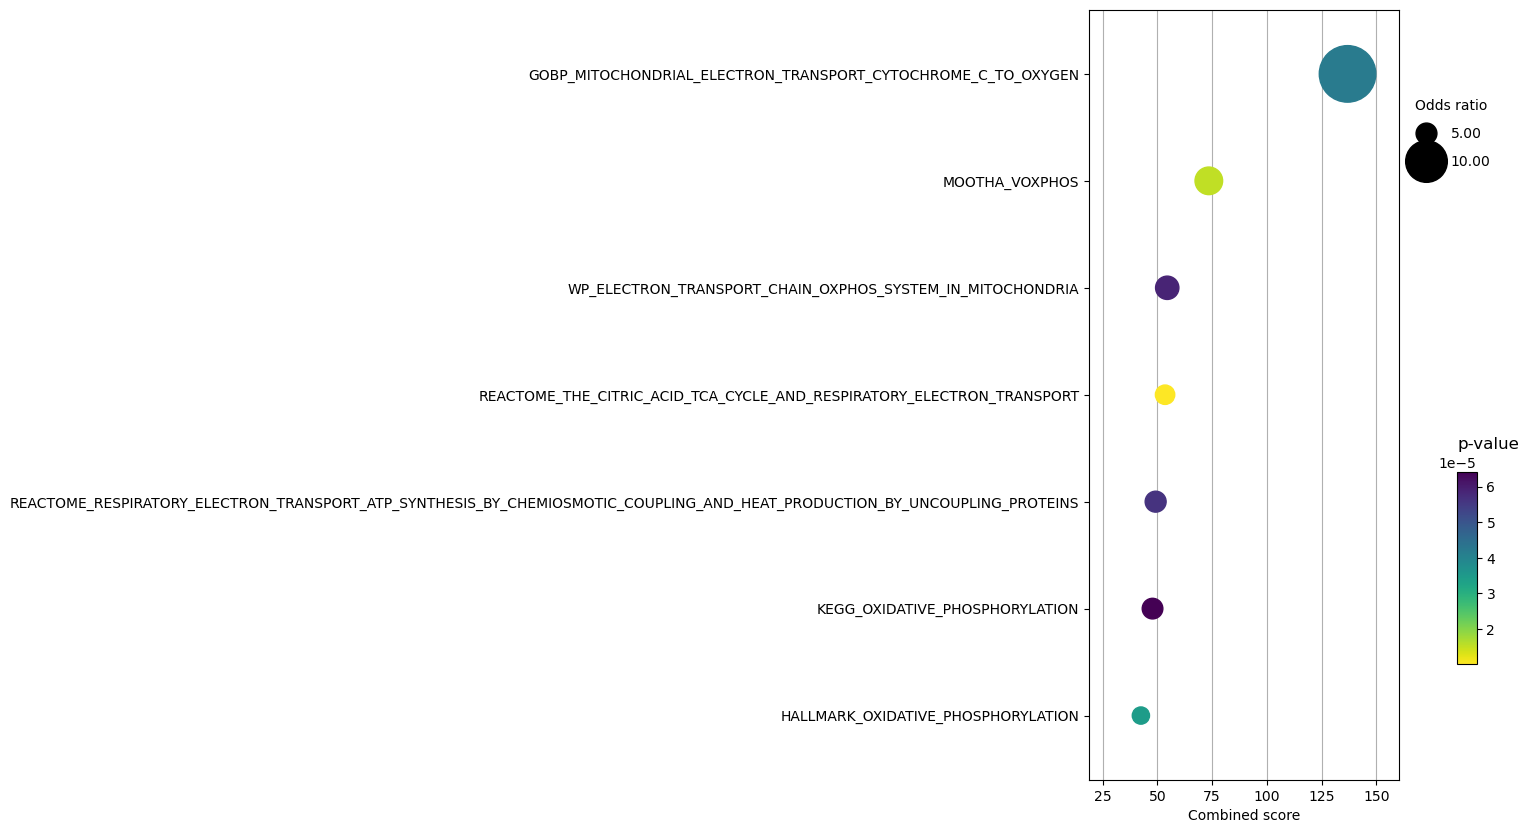

In [118]:
dc.plot_dotplot(
    significant_ORA.sort_values('Combined score', ascending=False).head(15),
    x='Combined score',
    y='Term',
    s='Odds ratio',
    c='p-value',
    scale=.5,
    figsize=(5, 10)
)

### GSEA vs ORA

In [119]:
enr_gsea[enr_gsea['Term'].isin(significant_ORA['Term'])].sort_values(by="NES")

NameError: name 'enr_gsea' is not defined

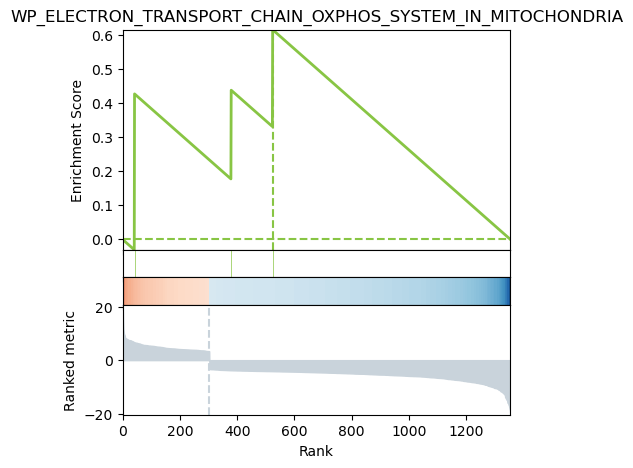

In [29]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb[msigdb['collection']=='wikipathways'],
    source='geneset',
    target='genesymbol',
    set_name='WP_ELECTRON_TRANSPORT_CHAIN_OXPHOS_SYSTEM_IN_MITOCHONDRIA'
)

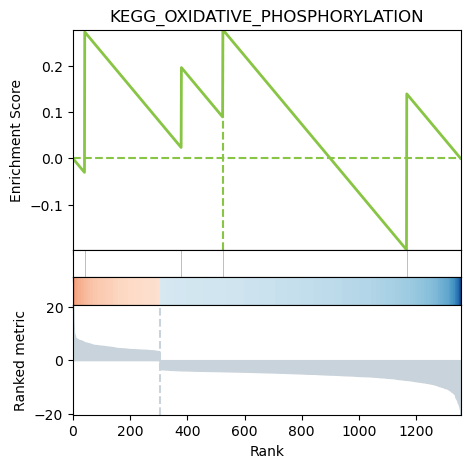

In [30]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb[msigdb['collection']=='kegg_pathways'],
    source='geneset',
    target='genesymbol',
    set_name='KEGG_OXIDATIVE_PHOSPHORYLATION'
)

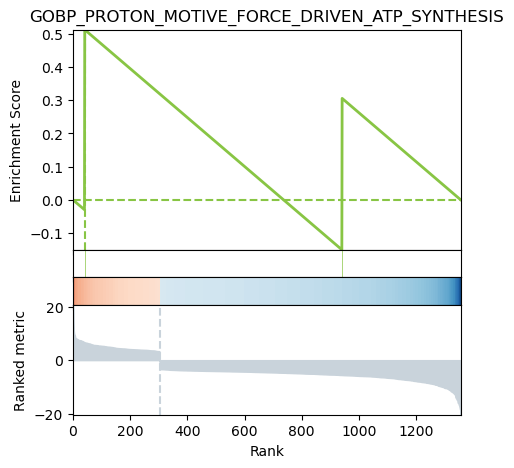

In [31]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb[msigdb['collection']=='go_biological_process'],
    source='geneset',
    target='genesymbol',
    set_name='GOBP_PROTON_MOTIVE_FORCE_DRIVEN_ATP_SYNTHESIS'
)

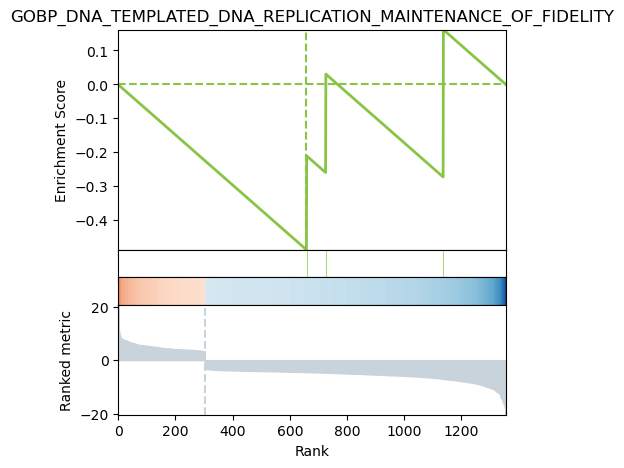

In [32]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb[msigdb['collection']=='go_biological_process'],
    source='geneset',
    target='genesymbol',
    set_name='GOBP_DNA_TEMPLATED_DNA_REPLICATION_MAINTENANCE_OF_FIDELITY'
)



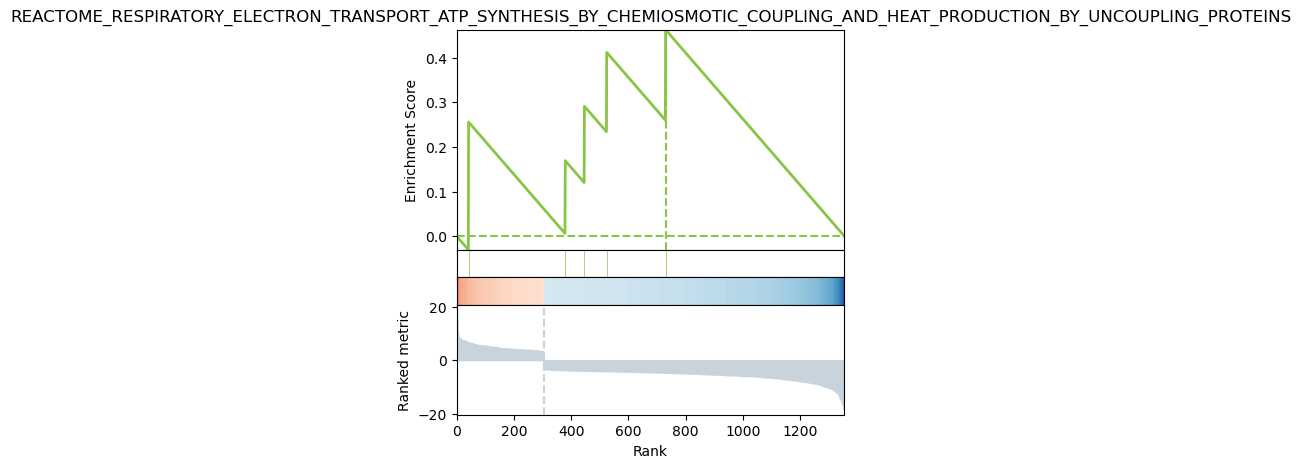

In [33]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb[msigdb['collection']=='reactome_pathways'],
    source='geneset',
    target='genesymbol',
    set_name='REACTOME_RESPIRATORY_ELECTRON_TRANSPORT_ATP_SYNTHESIS_BY_CHEMIOSMOTIC_COUPLING_AND_HEAT_PRODUCTION_BY_UNCOUPLING_PROTEINS'
)



In [26]:
set(msigdb["collection"])

{'biocarta_pathways',
 'cancer_gene_neighborhoods',
 'cancer_modules',
 'cell_type_signatures',
 'chemical_and_genetic_perturbations',
 'go_biological_process',
 'go_cellular_component',
 'go_molecular_function',
 'hallmark',
 'human_phenotype_ontology',
 'immunesigdb',
 'kegg_pathways',
 'mirna_targets_legacy',
 'mirna_targets_mirdb',
 'oncogenic_signatures',
 'pid_pathways',
 'positional',
 'reactome_pathways',
 'tf_targets_gtrf',
 'tf_targets_legacy',
 'vaccine_response',
 'wikipathways'}